# Week 2 — Personal Expenses Analysis

## Session 4 — Visualization and Correlation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

expenses_df = pd.read_csv(
    "expenses-with-features.csv",
    parse_dates=["Date"]
)

expenses_df

,Date,Category,Description,Amount,Payment_Method,Month,Needs_or_Wants,Large_Expense
0,2026-07-01,Food,Groceries,82.500000,Debit,July,Need,Yes
1,2026-07-02,Transportation,Bus pass,45.000000,Credit,July,Need,No
2,2026-07-03,Entertainment,Movie ticket,52.214286,Credit,July,Want,No
3,2026-07-04,Food,Restaurant,37.250000,Debit,July,Need,No
4,2026-07-05,Utilities,Phone bill,65.000000,Debit,July,Need,No
5,2026-07-06,Transportation,Taxi,22.500000,Cash,July,Need,No
6,2026-07-08,Unknown,Coffee,6.750000,Unknown,July,Want,No
7,2026-07-09,Shopping,Clothes,120.000000,Credit,July,Want,Yes


## 1. Spending by Category

In [2]:
category_totals = (
    expenses_df
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_totals

Category
Shopping          120.000000
Food              119.750000
Transportation     67.500000
Utilities          65.000000
Entertainment      52.214286
Unknown             6.750000
Name: Amount, dtype: float64

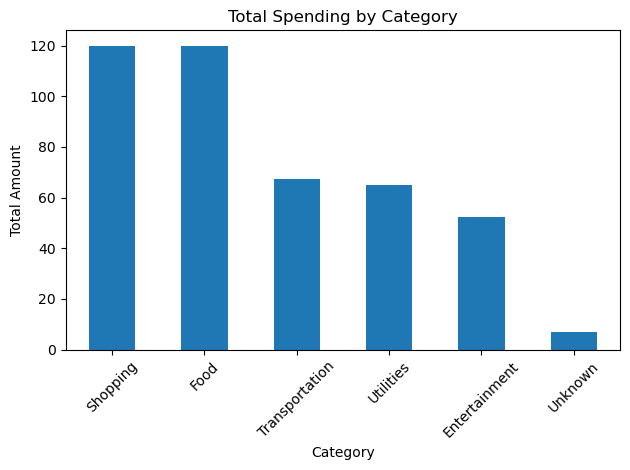

In [3]:
category_totals.plot(kind="bar", title="Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Spending Over Time

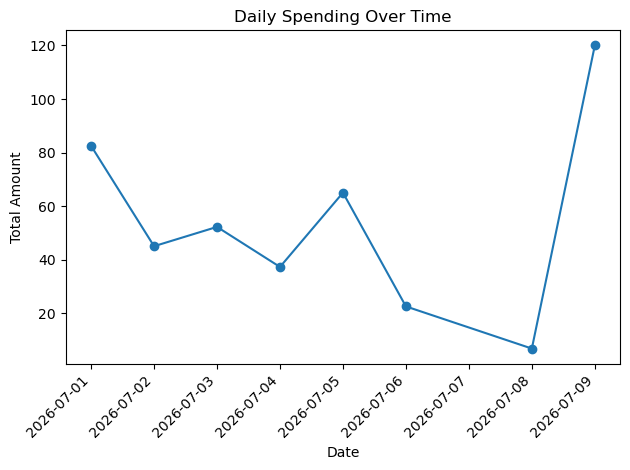

In [4]:
daily_spending = (
    expenses_df
    .groupby("Date")["Amount"]
    .sum()
)

daily_spending.plot(
    kind="line",
    marker="o",
    title="Daily Spending Over Time"
)

plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Expense Distribution

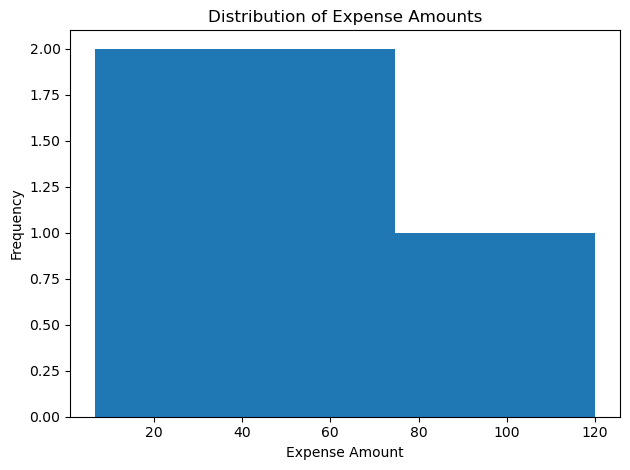

In [7]:
expenses_df["Amount"].plot(
    kind="hist",
    bins=5,
    title="Distribution of Expense Amounts"
)

plt.xlabel("Expense Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 4. Box Plot and Outliers

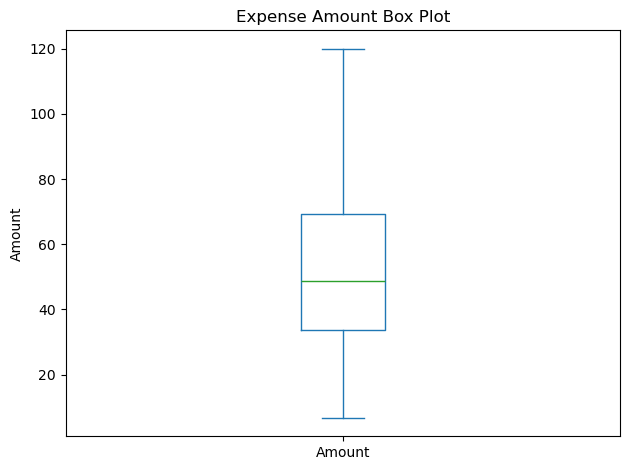

In [8]:
expenses_df["Amount"].plot(
    kind="box",
    title="Expense Amount Box Plot"
)

plt.ylabel("Amount")
plt.tight_layout()
plt.show()

## 5. Spending by Payment Method

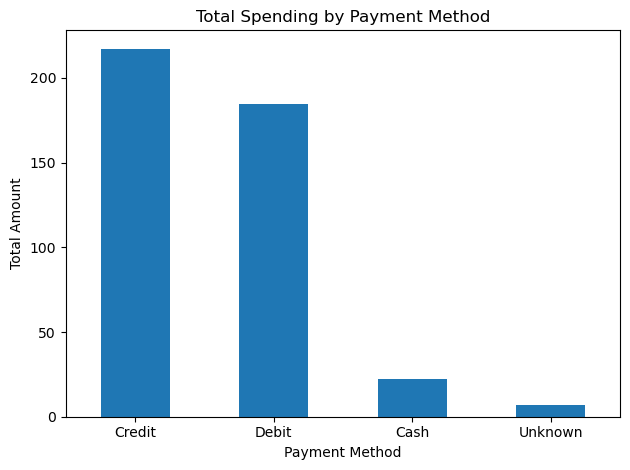

In [9]:
payment_totals = (
    expenses_df
    .groupby("Payment_Method")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

payment_totals.plot(
    kind="bar",
    title="Total Spending by Payment Method"
)

plt.xlabel("Payment Method")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

In [11]:
expenses_df["Transaction_Number"] = range(1, len(expenses_df) + 1)

correlation = expenses_df[
    ["Amount", "Transaction_Number"]
].corr()

correlation

,Amount,Transaction_Number
Amount,1.000000,0.008071
Transaction_Number,0.008071,1.000000


## 7. Scatter Plot

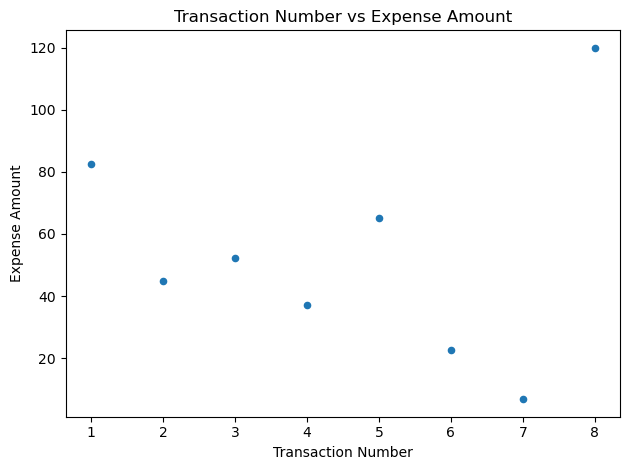

In [15]:
expenses_df.plot(
    kind="scatter",
    x="Transaction_Number",
    y="Amount",
    title="Transaction Number vs Expense Amount"
)

plt.xlabel("Transaction Number")
plt.ylabel("Expense Amount")
plt.tight_layout()
plt.show()

## 8. Identify Possible Outliers

In [16]:
q1 = expenses_df["Amount"].quantile(0.25)
q3 = expenses_df["Amount"].quantile(0.75)

iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

possible_outliers = expenses_df[
    (expenses_df["Amount"] < lower_limit) |
    (expenses_df["Amount"] > upper_limit)
]

print("Lower limit:", round(lower_limit, 2))
print("Upper limit:", round(upper_limit, 2))

possible_outliers

Lower limit: -20.16
Upper limit: 123.09


,Date,Category,Description,Amount,Payment_Method,Month,Needs_or_Wants,Large_Expense,Transaction_Number


## 9. Final Visualization Summary

In [17]:
print("Total number of expenses:", len(expenses_df))
print("Average expense:", round(expenses_df["Amount"].mean(), 2))
print("Highest expense:", expenses_df["Amount"].max())
print("Lowest expense:", expenses_df["Amount"].min())
print("Possible outliers:", len(possible_outliers))
print(
    "Correlation with transaction number:",
    round(correlation.loc["Amount", "Transaction_Number"], 2)
)

Total number of expenses: 8
Average expense: 53.9
Highest expense: 120.0
Lowest expense: 6.75
Possible outliers: 0
Correlation with transaction number: 0.01
